# Jawad Hassan
# 2230-0035
# BS AI
# ANN


# Lab 05

In [10]:
#libraries:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  
Epoch 1/50


/Users/macbook/Desktop/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 52.1490 - mae: 4.3238 - mse: 52.1490 - val_loss: 43.7930 - val_mae: 4.8700 - val_mse: 43.7930
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 26.0253 - mae: 3.5358 - mse: 26.0253 - val_loss: 41.1271 - val_mae: 4.6824 - val_mse: 41.1271
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 58.6306 - mae: 4.4888 - mse: 58.6306 - val_loss: 37.6305 - val_mae: 4.4567 - val_mse: 37.6305
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 43.5489 - mae: 3.8782 - mse: 43.5489 - val_loss: 34.2067 - val_mae: 4.2281 - val_mse: 34.2067
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 48.8499 - mae: 4.1842 - mse: 48.8499 - val_loss: 30.4408 - val_mae: 3.9691 - val_mse: 30.4408
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24.5990 - mae: 2.9065 - mse: 24.5990 - val_loss: 26.4788 - val_mae: 3.6806 - val_mse: 26.4788
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 27.3482 - mae: 3.1738 - mse: 27.3482 - v

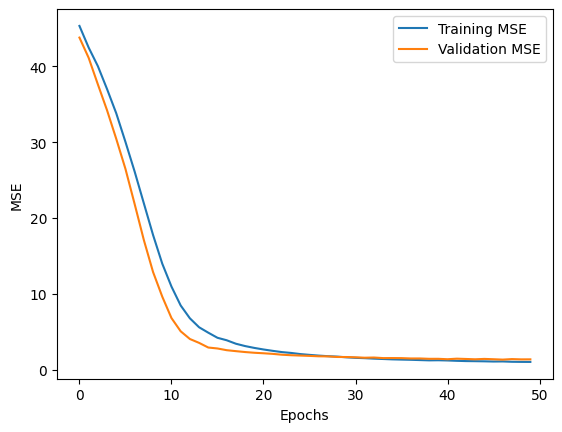

In [35]:
#task 1: Regression using Car Price Prediction Dataset
car=pd.read_csv('/Users/macbook/Desktop/sem6/ANN/lab5/car data.csv')
print(car.head())
car=car.drop('Car_Name',axis=1)
car['age']=2020-car['Year']
car=car.drop('Year',axis=1)
car=pd.get_dummies(car,columns=['Fuel_Type','Seller_Type','Transmission'],drop_first=True)
x=car.drop('Selling_Price',axis=1)
y=car['Selling_Price']
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)
scale=StandardScaler()
xtrainscaled=scale.fit_transform(xtrain)
xtestscaled=scale.transform(xtest)
model=Sequential()
model.add(Dense(16,activation='relu',input_dim=xtrainscaled.shape[1]))
model.add(Dense(8,activation='relu'))
model.add(Dense(1))
#using mse loss:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=["mae", "mse"]
)
history=model.fit(xtrainscaled,ytrain,epochs=50,batch_size=8,validation_split=0.2)
loss, mae, mse = model.evaluate(xtestscaled, ytest)
print(f"Test MAE: {mae}")
print(f"Test MSE: {mse}")

plt.plot(history.history["loss"], label="Training MSE")
plt.plot(history.history["val_loss"], label="Validation MSE")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.show()


Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.5950 - mae: 0.5950 - mse: 0.7952 - val_loss: 0.7648 - val_mae: 0.7648 - val_mse: 1.5505
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7414 - mae: 0.7414 - mse: 1.4119 - val_loss: 0.7550 - val_mae: 0.7550 - val_mse: 1.5089
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6329 - mae: 0.6329 - mse: 0.8748 - val_loss: 0.7564 - val_mae: 0.7564 - val_mse: 1.6279
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6983 - mae: 0.6983 - mse: 1.3553 - val_loss: 0.7501 - val_mae: 0.7501 - val_mse: 1.5687
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5463 - mae: 0.5463 - mse: 0.8183 - val_loss: 0.7636 - val_mae: 0.7636 - val_mse: 1.6801
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6158 - mae: 0.6158 - mse: 0.8722 - val_loss: 0.7230 - val_mae: 0.7230 - val_mse: 1.5467
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6390 - mae: 0.6390 - mse: 1.1930 - val_loss: 0.7102

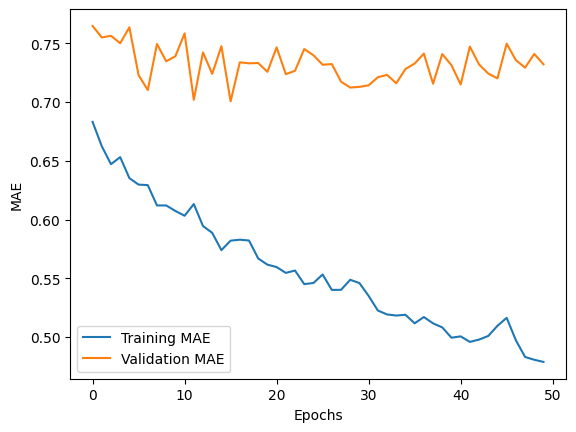

In [36]:
#using mae loss:
model.compile(
    optimizer='adam',
    loss='mae',
    metrics=["mae", "mse"]
)
history=model.fit(xtrainscaled,ytrain,epochs=50,batch_size=8,validation_split=0.2)
loss, mae, mse = model.evaluate(xtestscaled, ytest)
print(f"Test MAE: {mae}")
print(f"Test MSE: {mse}")

plt.plot(history.history["loss"], label="Training MAE")
plt.plot(history.history["val_loss"], label="Validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()


In [48]:
#task 2: Classification Loss using Email Spam Dataset

from sklearn.feature_extraction.text import TfidfVectorizer
# Use this code for the "v1, v2" comma-separated format
df = pd.read_csv(
    '/Users/macbook/Desktop/sem6/ANN/lab5/spam.csv', 
    encoding='latin-1',
    usecols=[0, 1],             # Only take the first two columns (v1 and v2)
    names=['Type', 'Message'],  # Rename them to something useful
    skiprows=1                  # Skip the 'v1,v2,,,' header line
)

# Clean up any trailing characters if necessary
df['Type'] = df['Type'].str.lower().str.strip()

print(df.head())

#  Encode the labels (spam = 1, ham = 0)
df['Label'] = df['Type'].map({'ham': 0, 'spam': 1})

#  Convert text messages into numerical features (TF-IDF)
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
x = tfidf.fit_transform(df['Message']).toarray()
y = df['Label'].values

# Split data for training and testing
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

#build model:
model = Sequential([
    Dense(16, activation='relu', input_shape=(xtrain.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

#  Compile the model using Binary Cross Entropy loss
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])
#  Train the model
history = model.fit(xtrain, ytrain, epochs=10, validation_data=(xtest, ytest), batch_size=32)

# Evaluate the final results
loss, accuracy = model.evaluate(xtest, ytest)
print(f"\nFinal Test Loss: {loss:.4f}")
print(f"Final Test Accuracy: {accuracy:.4f}")

   Type                                            Message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Epoch 1/10


/Users/macbook/Desktop/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8409 - loss: 0.5977 - val_accuracy: 0.8655 - val_loss: 0.2774
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8861 - loss: 0.2298 - val_accuracy: 0.9677 - val_loss: 0.1327
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9770 - loss: 0.0975 - val_accuracy: 0.9776 - val_loss: 0.0845
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9874 - loss: 0.0485 - val_accuracy: 0.9785 - val_loss: 0.0724
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9905 - loss: 0.0388 - val_accuracy: 0.9776 - val_loss: 0.0715
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9931 - loss: 0.0289 - val_accuracy: 0.9785 - val_loss: 0.0718
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9949 - loss: 0.0196 - val_accuracy: 0.9803 - val_loss: 0.0736
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9968 - loss: 0.0184 - val_accuracy: 0.9803 - val_